# PROJECT TITLE:- Machine Learning-Based Diabetes Prediction System

### Problem Statement:- Diabetes is a rapidly increasing chronic  disease caused by factors such as high glucose levels, obesity, genetic history, and lifestyle habits. Early detection is difficult but crucial to prevent severe complications. This project aims to develop a machine learning-based predictive system to identify individuals at risk of diabetes using medical attributes.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [2]:
import pandas as pd
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (768, 9)


In this step, essential Python libraries are imported to perform data analysis, visualization, and machine learning tasks. NumPy and Pandas are used for data manipulation, while Matplotlib and Seaborn are used for data visualization. Scikit-learn provides tools for data preprocessing, model training (Random Forest, Logistic Regression, SVM, etc.), and performance evaluation using metrics like accuracy, confusion matrix, and ROC curve.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [5]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print(df.shape)
print(df.info())
print(df.describe())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479  

Data Cleaning:- In this step, we check for missing and invalid values in the dataset to ensure data quality. Although the dataset does not contain null values, some medical attributes such as Glucose, Blood Pressure, BMI, and Insulin contain zero values, which are medically unrealistic. To maintain data integrity and improve model accuracy, these zero values are replaced with the mean of their respective columns. This preprocessing step ensures that the model learns from meaningful and reliable data.

In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
columns = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in columns:
    df[col] = df[col].replace(0, df[col].mean())

Exploratory Data Analysis (EDA) is performed to understand the distribution and relationships within the dataset before building the model. Histogram plots help visualize how individual features such as glucose, BMI, and age are distributed. The correlation heatmap shows the relationship between variables and helps identify which features are strongly associated with the target variable . This step provides insights that improve model understanding and performance.

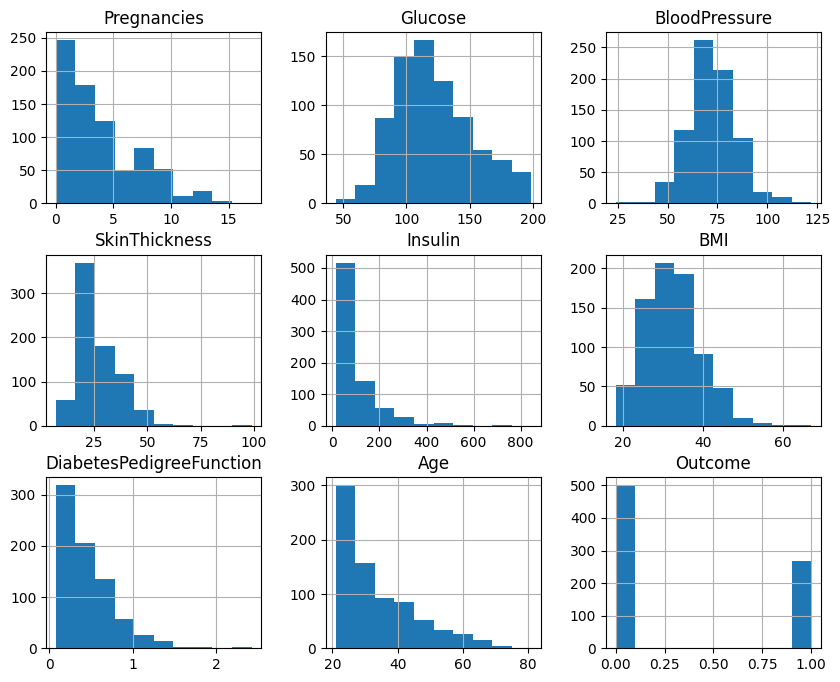

In [ ]:
df.hist(figsize=(10,8))
plt.show()

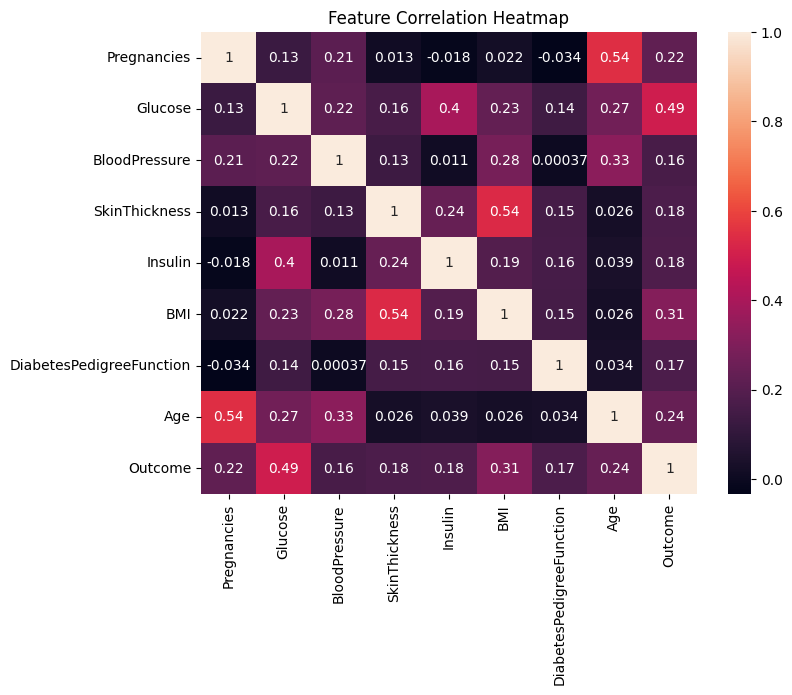

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training Model

Machine learning models are implemented to identify hidden patterns in medical data and accurately classify patients as diabetic or non-diabetic. Advanced algorithms like Random Forest and XGBoost improve prediction accuracy and help in early detection of diabetes risk.

Random Forest:- Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their outputs to improve prediction accuracy. It reduces overfitting by averaging the results of many trees trained on different subsets of data. It is robust, handles non-linear relationships well, and performs effectively for classification problems like diabetes prediction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
rf_acc = rf.score(X_test, y_test)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7467532467532467


Gradient Boosting:- Gradient Boosting is an advanced ensemble technique that builds models sequentially, where each new model corrects the errors made by the previous one. It optimizes performance by minimizing a loss function using gradient descent. This method improves accuracy and is particularly powerful for structured datasets.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train)
gb_acc = gb.score(X_test, y_test)

print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 0.7532467532467533


XGBoost:- XGBoost (Extreme Gradient Boosting) is an optimized and efficient implementation of gradient boosting. It improves model performance through regularization, parallel processing, and efficient handling of missing data. XGBoost is widely used in machine learning competitions due to its high accuracy and speed.

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
xgb_acc = xgb.score(X_test, y_test)

print("XGBoost Accuracy:", xgb_acc)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:48:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7272727272727273


SVM:- Support Vector Machine is a supervised learning algorithm that classifies data by finding the optimal hyperplane that separates classes. Using the RBF kernel allows it to handle non-linear decision boundaries effectively. It performs well in high-dimensional spaces and is suitable for medical classification tasks.

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=2, gamma='scale', probability=True)

svm.fit(X_train, y_train)
svm_acc = svm.score(X_test, y_test)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.7272727272727273


In [ ]:
import pandas as pd

models = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost', 'SVM'],
    'Accuracy': [rf_acc, gb_acc, xgb_acc, svm_acc]
})

print(models)

               Model  Accuracy
0      Random Forest  0.746753
1  Gradient Boosting  0.753247
2            XGBoost  0.727273
3                SVM  0.727273


Confusion Matrix:- A Confusion Matrix is used to evaluate the performance of a classification model by comparing actual and predicted values. It displays four important components: True Positives, True Negatives, False Positives, and False Negatives. This helps in understanding how well the model correctly identifies diabetic and non-diabetic patients beyond simple accuracy.

Confusion Matrix:
 [[75 24]
 [18 37]]


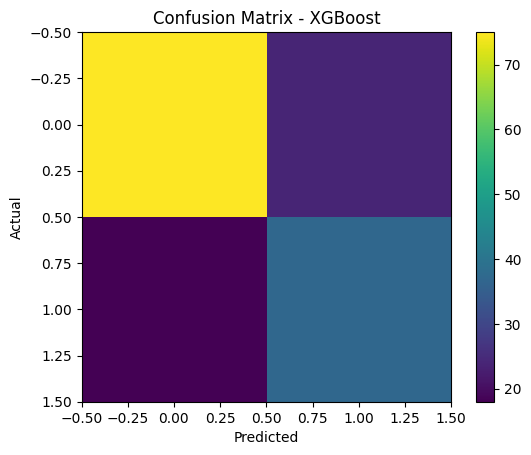

In [ ]:
from sklearn.metrics import confusion_matrix

# Predict using XGBoost
y_pred = xgb.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.76      0.78        99
           1       0.61      0.67      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



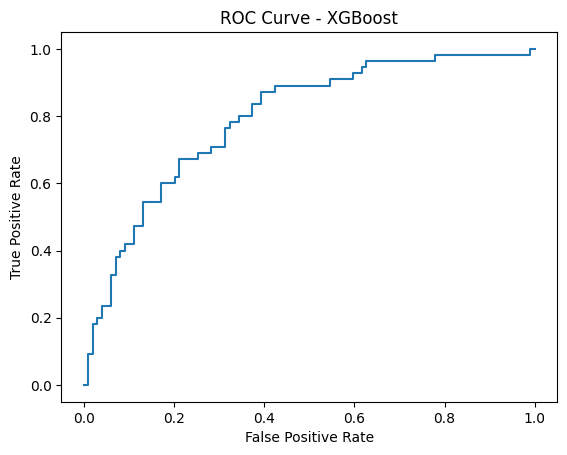

AUC Score: 0.7924701561065197


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores
y_prob = xgb.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

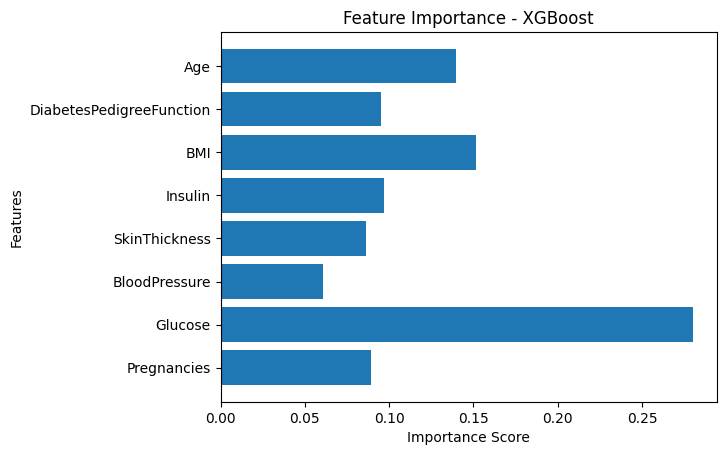

In [ ]:
import numpy as np

importances = xgb.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Custom Prediction:- In this step, the trained model is tested with new patient input data. The system processes the medical parameters and predicts whether the individual is diabetic or not. This demonstrates the practical application of the machine learning model in real-world healthcare scenarios.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Cross Validation Scores: [0.78571429 0.72077922 0.73376623 0.78431373 0.74509804]
Mean CV Accuracy: 0.7539343009931245
